This is an attempt to drastically speed up the drizzle-like approach from [single_forward_model4_build2d.ipynb](single_forward_model4_build2d.ipynb) using Nvidia Numba custom kernels, following the struggles of regular JAX in [jax_build2d.ipynb](jax_build2d.ipynb).  Note, all data are fake but of comparable dimension.

In [1]:
import math

from matplotlib import pyplot as plt

import numpy as np
from numba import cuda, float32
import cupy as cp

do_timing_run = True

# Mock data

Make fake "data" of a dimensionality that's not crazy, and populate it with some random nans

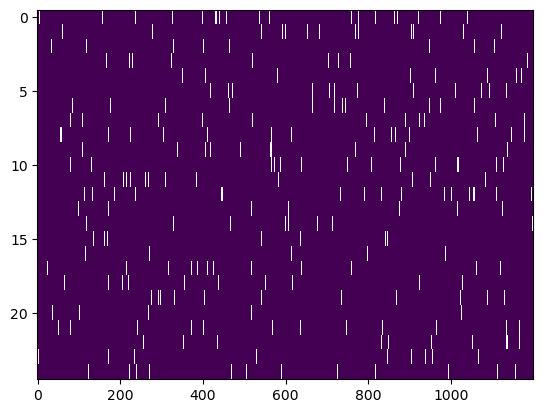

In [2]:
slit = np.zeros((25, 1200))

nanmsk = np.random.uniform(size=slit.shape)>.98

slit[nanmsk] = np.nan*slit[nanmsk]

plt.imshow(slit,aspect='auto', interpolation='nearest')

Make a fake spectrum that's somewhat denser than the "data"

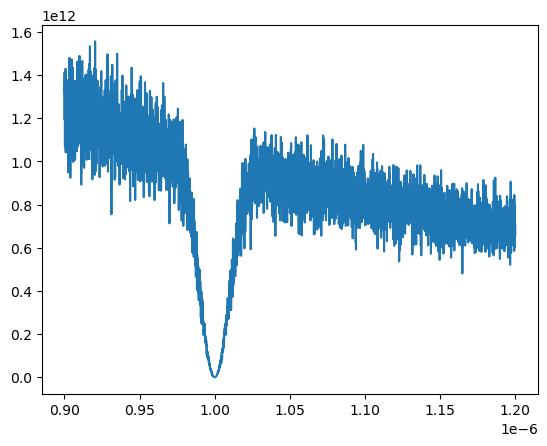

In [3]:
wave_m = np.linspace(0.9e-6, 1.2e-6, 4096)
spectrum = np.ones_like(wave_m)

# this spectrum is artificially noisy with a single bit aborption line.
spectrum = spectrum + 0.1 * np.random.normal(size=spectrum.shape)
spectrum = spectrum * (1-np.exp(-0.5*((wave_m - 1.e-6)/10e-9)**2))
spectrum_fnu = spectrum  * wave_m**-2

plt.plot(wave_m, spectrum_fnu)

Make a fake slightly noisy psf that is ~200x200 with 10x oversampling

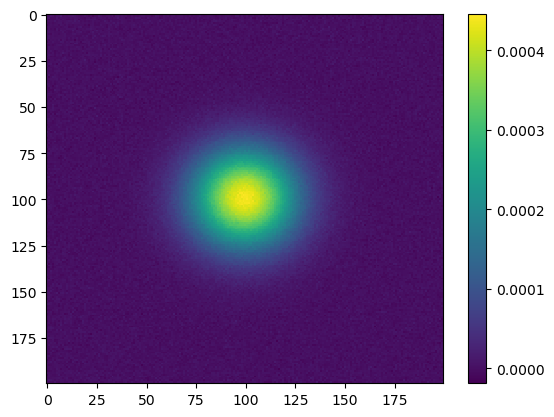

In [4]:
psf_box = (20,20)
oversampling = 10

psfcen_x = psfcen_y = 0

ys, xs = np.indices((psf_box[0]*oversampling, psf_box[1]*oversampling)).astype(float)
ys -= (ys.shape[0]-1)/2
xs -= (xs.shape[1]-1)/2

psf_x = (xs - psfcen_x)/oversampling
psf_y = (ys - psfcen_y)/oversampling

os_psf = np.exp(-0.5*(psf_x**2 + psf_y**2)/(1.9**2))

os_psf = os_psf + 0.01 * np.random.normal(size=os_psf.shape)

os_psf = os_psf / np.sum(os_psf)

plt.imshow(os_psf, aspect='auto', interpolation='nearest')
plt.colorbar()

And now make a spectral trace that's curvy

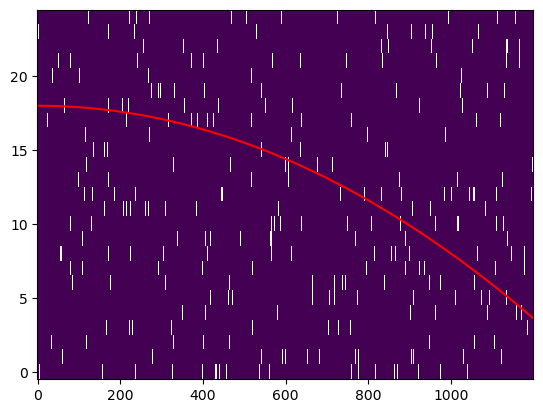

In [5]:
def tracefunc(x):
    return 18 - 10*(x/1000)**2

xtrace = np.arange(slit.shape[1])
ytrace = tracefunc(xtrace)

plt.imshow(slit,aspect='auto', interpolation='nearest', origin='lower')
plt.plot(xtrace, ytrace, color='red')

Note the biggest difference is that the real data have a lot more nans, but this smattering should be sufficient to catch relevant bugs.

In [6]:
xspec = np.arange(wave_m.size)/wave_m.size * slit.shape[1]
yspec = tracefunc(xspec)

# Algorithmic experimentation

In general we always take the grid to be the shape of the output pixels and hence can use the grid as a stand-in for the  slit shape.

Some  key assumptions of the below algorithms that provide speed:
* The spectral point density is such that the number of spectral points that influence a output pixel is no more than 1024 (max number of threads per block)
* The spectrum bends monotonically such that the spectral region of relevance is always a single uninterrupted block iun the spectrum array order (this could be relaxed for probably a smallish algorithmic cost)

In [7]:
maxpsf = max(np.max(psf_x), np.max(psf_y)).astype(np.float32).ravel()

@cuda.jit
def compute_influence(xspec, yspec, startidx, nspec):
    maxpsfc = cuda.const.array_like(maxpsf)  # not sure if this helps any but it at least shows that this  works

    x = cuda.blockIdx.x
    y = cuda.blockIdx.y

    idx = y * cuda.blockDim.x + x

    startidxi = -1
    count = 0
    for i, (xs, ys) in enumerate(zip(xspec, yspec)):
        if abs(x - xs) <= maxpsfc[0]:  #TODO: might need some buffer?
            if abs(y - ys) <= maxpsfc[0]:
                count += 1
                if startidxi == -1:
                    startidxi = i
    
    startidx[y, x] = startidxi
    nspec[y, x] = count
                

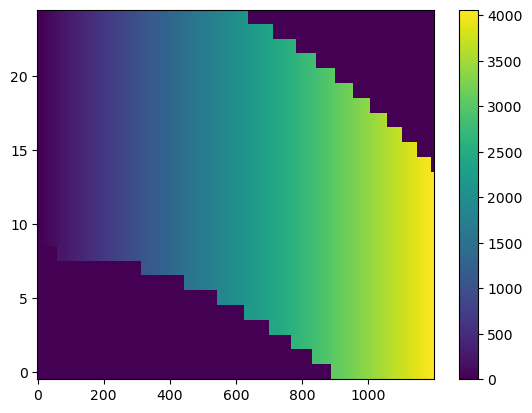

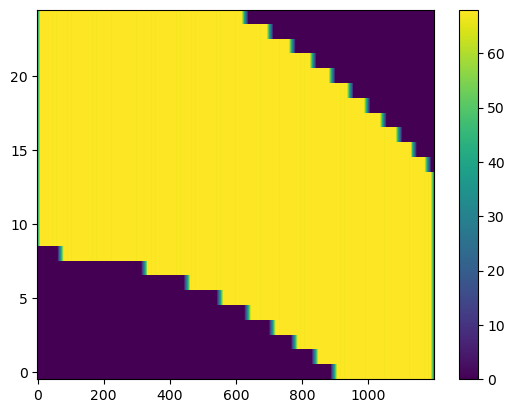

In [8]:
xspecc = cuda.to_device(xspec)
yspecc = cuda.to_device(yspec)
startidxc = cuda.device_array(slit.shape, dtype=np.int32)
nspecc = cuda.device_array(slit.shape, dtype=np.int32)

# one thread per block is wasteful but this is just a test.
compute_influence[slit.shape[::-1], 1](xspecc, yspecc, startidxc, nspecc)

plt.figure()
plt.imshow(startidxc, aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

plt.figure()
plt.imshow(nspecc, aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

Try having the blocks be over the influencing spec points

In [9]:
longest_stretch = int(cp.array(nspecc, copy=False).max())
longest_stretch32 = math.ceil(longest_stretch / 32) * 32
assert longest_stretch32 <= 1024, 'Only 1024 threads per block'
print(longest_stretch, longest_stretch32)

gridspec = slit.shape[::-1]
blockspec = longest_stretch32
kernelspec = (gridspec, blockspec)
kernelspec

68 96


((1200, 25), 96)

In [10]:

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan

result = np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1)
np.sum(np.isnan(result[..., -1]))

np.int64(608)

201.01260375976562 ms


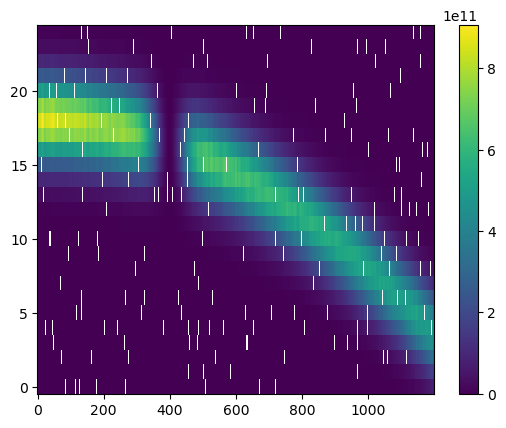

In [11]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)
def scatter_flux(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xf = float32(x)
    yf = float32(y)
    for i in range(psf_x.shape[0]):
        for j in range(psf_x.shape[1]):
            xpi = xsi + psf_x[i, j] - xf
            ypi = ysi + psf_y[i, j] - yf

            ox = pixel_slope * abs(xpi) + pixel_intercept
            if ox > 1:
                ox = float32(1)
            elif ox < 0:
                ox = float32(0)
            oy = pixel_slope * abs(ypi) + pixel_intercept
            if oy > 1:
                oy = float32(1)
            elif oy < 0:
                oy = float32(0)
 
            flux_contrib += ox*oy*fsi*psf_flux[i, j]
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.astype(np.float32))
psf_yc = cuda.to_device(psf_y.astype(np.float32))
psf_flux = cuda.to_device(os_psf.astype(np.float32))

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 


    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

Try some simple optimizations after looking at the profiler results:

152.37490844726562 ms


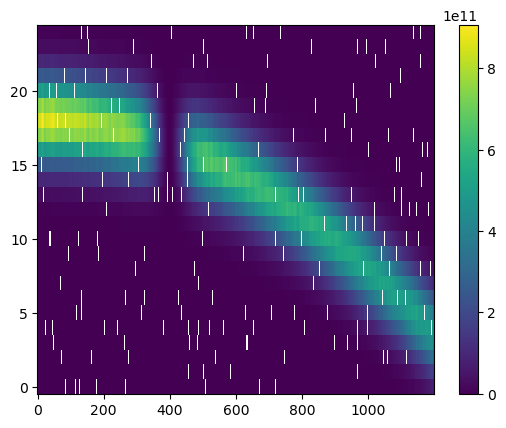

In [12]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v2(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)
    for i in range(psf_x.shape[0]):
        for j in range(psf_x.shape[1]):
            xpi = xo + psf_x[i, j]
            ypi = yo + psf_y[i, j]

            ox = pixel_slope * abs(xpi) + pixel_intercept
            oy = pixel_slope * abs(ypi) + pixel_intercept

            if ox <= 0 or oy <= 0:
                continue

            ox = max(float32(0), min(float32(1), ox))
            oy = max(float32(0), min(float32(1), oy))


            flux_contrib += ox*oy*fsi*psf_flux[i, j]
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.astype(np.float32))
psf_yc = cuda.to_device(psf_y.astype(np.float32))
psf_flux = cuda.to_device(os_psf.astype(np.float32))

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v2[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v2[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 

    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

115.71981048583984 ms


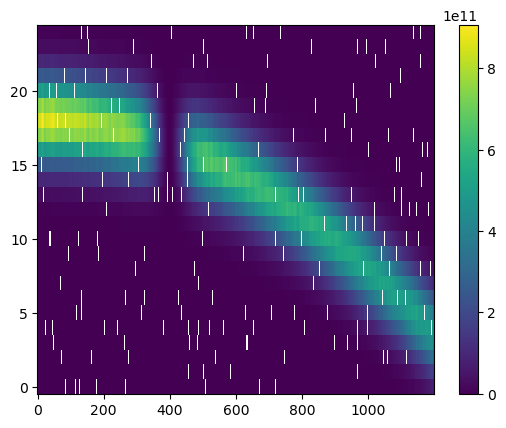

In [13]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v3(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)
    for i in range(psf_x.shape[0]):
        xpi = xo + psf_x[i]
        ypi = yo + psf_y[i]

        ox = pixel_slope * abs(xpi) + pixel_intercept
        oy = pixel_slope * abs(ypi) + pixel_intercept

        if ox <= 0 or oy <= 0:
            continue

        ox = max(float32(0), min(float32(1), ox))
        oy = max(float32(0), min(float32(1), oy))


        flux_contrib += ox*oy*fsi*psf_flux[i]
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.flatten().astype(np.float32))
psf_yc = cuda.to_device(psf_y.flatten().astype(np.float32))
psf_flux = cuda.to_device(os_psf.flatten().astype(np.float32))

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v3[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v3[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 

    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

Now try to implement some logic to make the loop over the psf shorter. In practice nearly all of the overlaps should be 0 since it's only one physical pixel visited by each thread in the block.

Start by trying to empirically determine what is influencing what

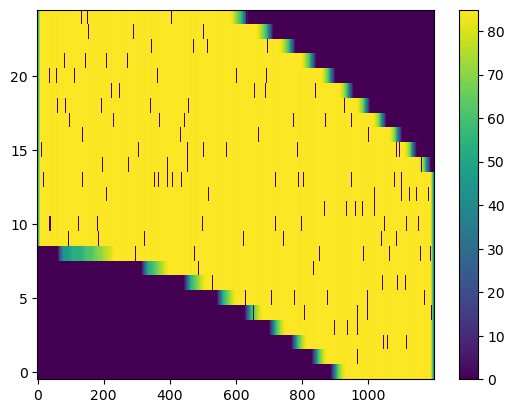

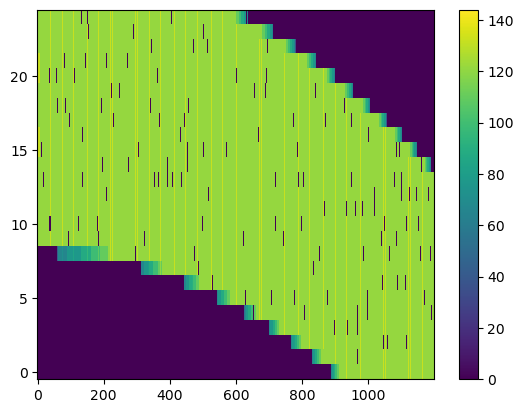

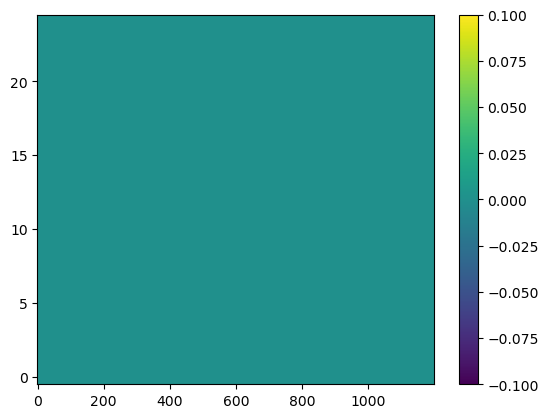

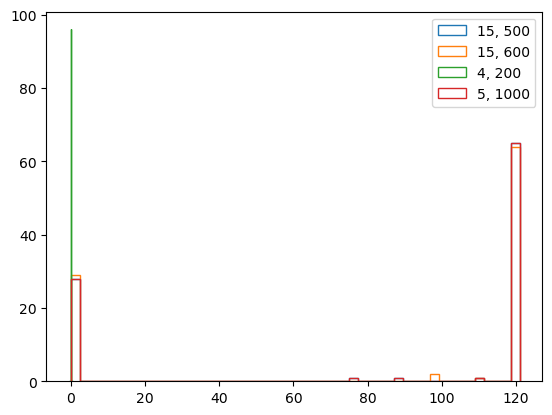

In [14]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_contrib_count(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outcontrib):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)
    nnonzero = 0
    for i in range(psf_x.shape[0]):
        xpi = xo + psf_x[i]
        ypi = yo + psf_y[i]

        ox = pixel_slope * abs(xpi) + pixel_intercept
        oy = pixel_slope * abs(ypi) + pixel_intercept

        if ox <= 0 or oy <= 0:
            continue
        nnonzero += 1

        ox = max(float32(0), min(float32(1), ox))
        oy = max(float32(0), min(float32(1), oy))


        flux_contrib += ox*oy*fsi*psf_flux[i]
    outcontrib[y, x, tidx] = nnonzero

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.flatten().astype(np.float32))
psf_yc = cuda.to_device(psf_y.flatten().astype(np.float32))
psf_flux = cuda.to_device(os_psf.flatten().astype(np.float32))

slitarr = np.zeros_like(slit)
outcontrib = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_contrib_count[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outcontrib)

plt.imshow(np.mean(outcontrib.copy_to_host(),axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

plt.figure()
plt.imshow(np.max(outcontrib.copy_to_host(),axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

plt.figure()
plt.imshow(np.min(outcontrib.copy_to_host(),axis=-1), aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()

yis = [15, 15,4,5]
xis = [500, 600,200,1000]

plt.figure()
for yi, xi in zip(yis, xis):
    plt.hist(outcontrib[yi, xi, :].copy_to_host(), bins=50, label=f'{yi}, {xi}',histtype='step')
plt.legend()

## Dont visit every psf pixel everytime

So an output array of length ~200 should be sufficient to record which pixels talk to that output pixel.  The below kernel does that by populating an array that is the (flattened) index of the contributing psf pixel, or -1 if there isn't one.

A key assumption added to the below is that the psf is a uniform grid

In [15]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_contrib_coo(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outcontrib, outcontribs):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)
    nnonzero = 0
    j = 0
    for i in range(psf_x.shape[0]):
        xpi = xo + psf_x[i]
        ypi = yo + psf_y[i]

        ox = pixel_slope * abs(xpi) + pixel_intercept
        oy = pixel_slope * abs(ypi) + pixel_intercept

        if ox <= 0 or oy <= 0:
            continue

        ox = max(float32(0), min(float32(1), ox))
        oy = max(float32(0), min(float32(1), oy))

        outcontrib[y, x, tidx, j] = i
        outcontribs[y, x, tidx, j] = specidx
        j += 1

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.flatten().astype(np.float32))
psf_yc = cuda.to_device(psf_y.flatten().astype(np.float32))
psf_flux = cuda.to_device(os_psf.flatten().astype(np.float32))

slitarr = np.zeros_like(slit)
outcontrib = cuda.to_device(-np.ones((kernelspec[0][1], kernelspec[0][0], kernelspec[-1], 200), dtype=int))
outcontribs = cuda.to_device(-np.ones((kernelspec[0][1], kernelspec[0][0], kernelspec[-1], 200), dtype=int))


scatter_flux_contrib_coo[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outcontrib, outcontribs)
a = outcontrib.copy_to_host()
b = outcontribs.copy_to_host()
a.shape, b.shape

((25, 1200, 96, 200), (25, 1200, 96, 200))

a and b are the 1d indecies indo the psf and the spectral arrays, respectively.

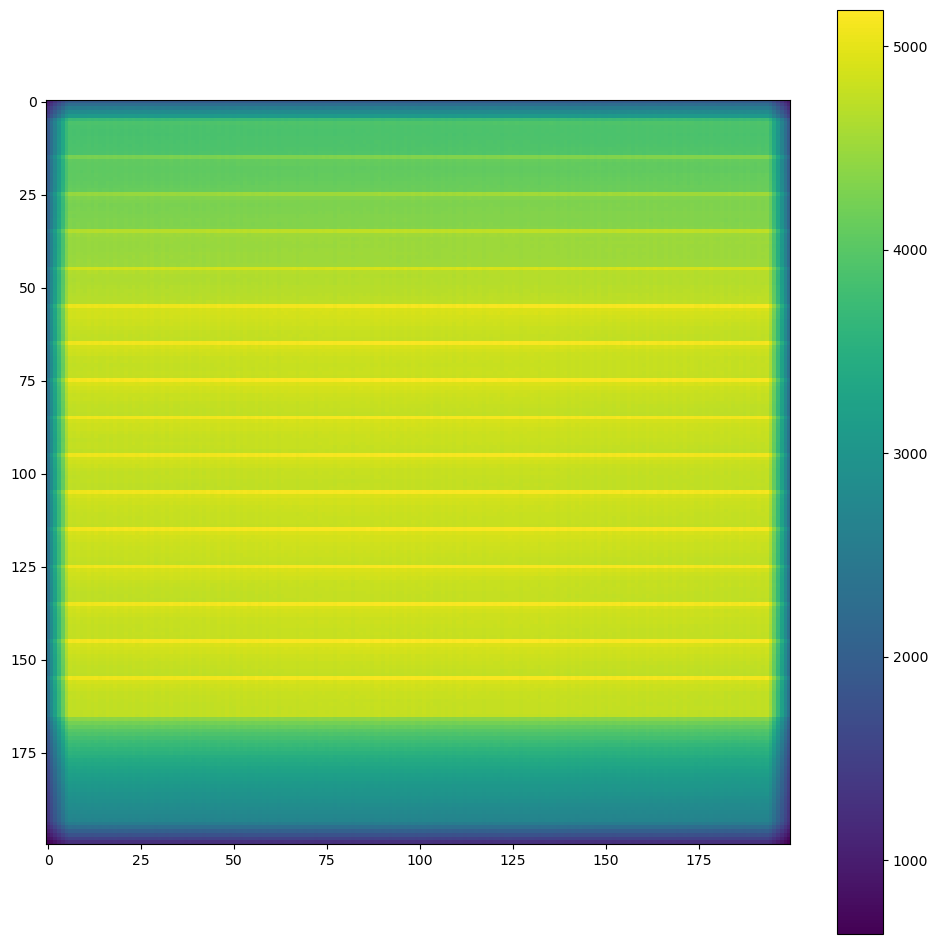

In [16]:
uvals, ucounts = np.unique(a, return_counts=True)
assert np.where(ucounts[uvals==-1])[0]==0

uvals = uvals[1:]
ucounts = ucounts[1:]

plt.figure(figsize=(12, 12))
plt.imshow(ucounts.reshape(200,200))
plt.colorbar()

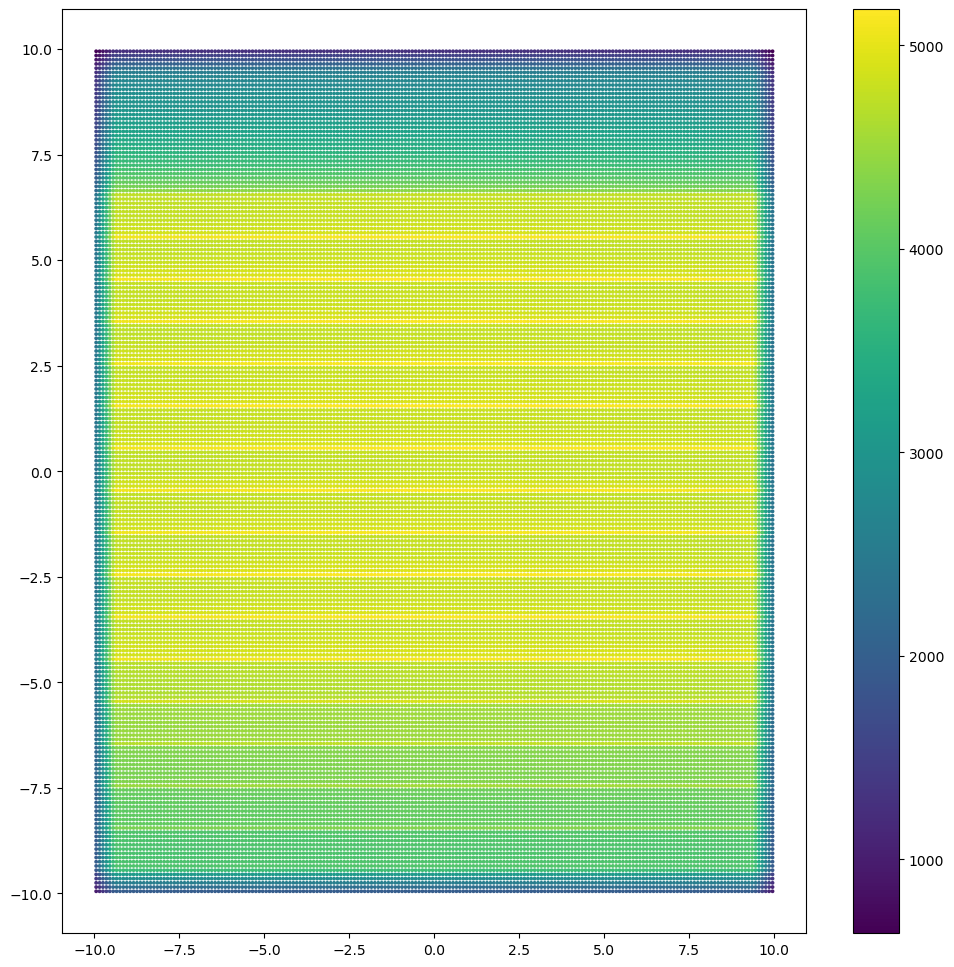

In [17]:
ux = psf_x.ravel()[uvals]
uy = psf_y.ravel()[uvals]

plt.figure(figsize=(12, 12))
plt.scatter(psf_x, psf_y, c=ucounts,s=3)
plt.colorbar()

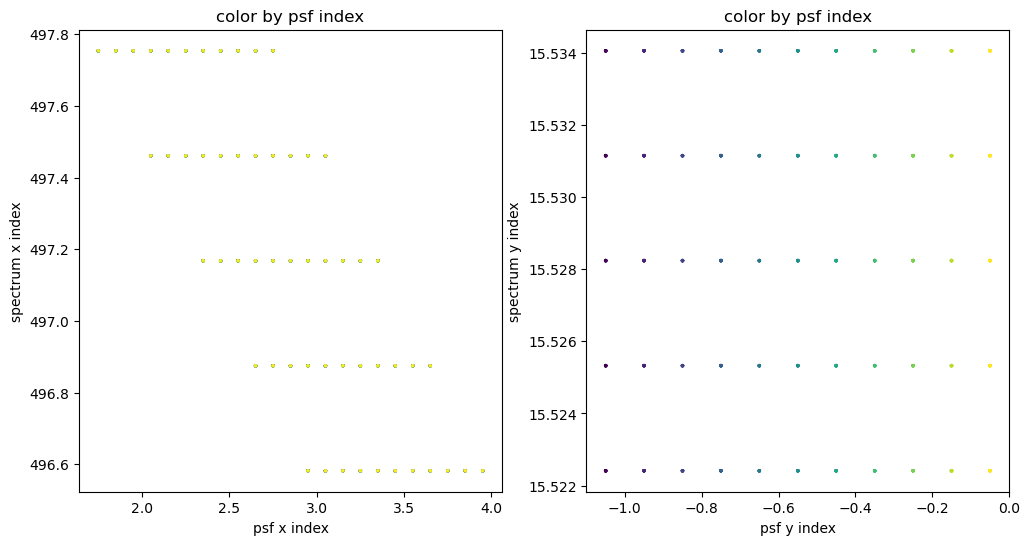

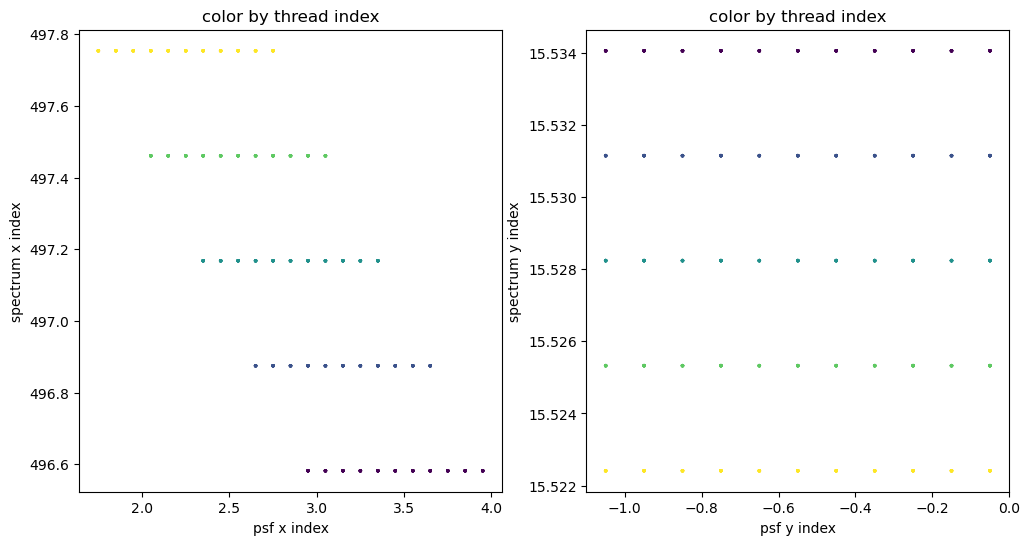

In [18]:
xi = 500
yi = 15
ti = slice(22,27)

ai = a[yi, xi, ti]
bi = b[yi, xi, ti]

if len(bi.shape)>1:
    tii = np.arange(bi.shape[0])
    tii = np.repeat(tii, bi.shape[-1]).reshape(*bi.shape)
else:
    tii = np.ones_like(bi)*ti


assert np.all((ai==-1) == (bi==-1))  # check the assumption that these are the same mask
aii = ai[ai!=-1]
bii = bi[ai!=-1]
tii = tii[ai!=-1]

pxii = psf_x.ravel()[aii]
pyii = psf_y.ravel()[aii]
pyidx, pxidx = np.indices(psf_x.shape)
pyidxi = pyidx.ravel()[aii]
pxidxi = pxidx.ravel()[aii]
xspecii = xspec[bii]
yspecii = yspec[bii]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(pxii, xspecii, s=2, c=aii)
ax1.set_xlabel('psf x index')
ax1.set_ylabel('spectrum x index')
ax1.set_title('color by psf index')
ax2.scatter(pyii, yspecii, s=2, c=aii)
ax2.set_xlabel('psf y index')
ax2.set_ylabel('spectrum y index')
ax2.set_title('color by psf index')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(pxii, xspecii, s=2, c=tii)
ax1.set_xlabel('psf x index')
ax1.set_ylabel('spectrum x index')
ax1.set_title('color by thread index')
ax2.scatter(pyii, yspecii, s=2, c=tii)
ax2.set_xlabel('psf y index')
ax2.set_ylabel('spectrum y index')
ax2.set_title('color by thread index');

In [19]:
rngact = np.array(((xi - xspecii - 1/2 - 1/oversampling), (xi - xspecii + 1/2 + 1/oversampling), pxii))
rngact.T

array([[2.81796875, 4.01796875, 2.95      ],
       [2.81796875, 4.01796875, 3.05      ],
       [2.81796875, 4.01796875, 3.15      ],
       ...,
       [1.64609375, 2.84609375, 2.55      ],
       [1.64609375, 2.84609375, 2.65      ],
       [1.64609375, 2.84609375, 2.75      ]], shape=(605, 3))

In [20]:
np.all(rngact[0] < rngact[1])

np.True_

In [21]:
np.all(rngact[0] < rngact[2])

np.True_

In [22]:
np.all(rngact[1] > rngact[2])

np.True_

So that spacing above does provide a bounding region

In [23]:
(psf_x[0] - psf_x[0][0])*oversampling

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

And the above is a good way to convert from pixel num to index

6.706431865692139 ms


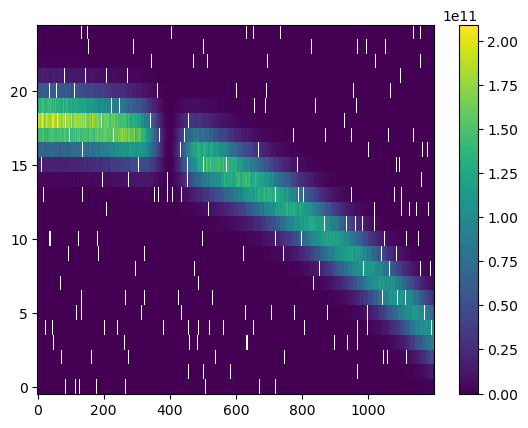

In [24]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v4(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)

    xlower = int(math.floor((x - xsi - 1/2)*oversampling - 1) + psf_x.shape[0]/2)
    xupper = int(math.ceil((x - xsi + 1/2)*oversampling + 2) + psf_x.shape[0]/2)
    ylower = int(math.floor((y - ysi - 1/2)*oversampling - 1) + psf_x.shape[1]/2)
    yupper = int(math.ceil((y - ysi + 1/2)*oversampling + 2) + psf_x.shape[1]/2)

    for i in range(xlower, xupper):
        for j in range(ylower, yupper):
            xpi = xo + psf_x[i, j]
            ypi = yo + psf_y[i, j]

            ox = pixel_slope * abs(xpi) + pixel_intercept
            oy = pixel_slope * abs(ypi) + pixel_intercept

            if ox <= 0 or oy <= 0:
                continue

            ox = max(float32(0), min(float32(1), ox))
            oy = max(float32(0), min(float32(1), oy))


            flux_contrib += ox*oy*fsi*psf_flux[i, j]
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.astype(np.float32))
psf_yc = cuda.to_device(psf_y.astype(np.float32))
psf_flux = cuda.to_device(os_psf.astype(np.float32))

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v4[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
#plt.imshow(outslitall.copy_to_host()[..., 0], aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v4[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 


    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

The primary performance limit here is now iterating over the psf and having uncoalesced global accesses. Would need to re-work the kernel to have the warps be over the psf instead of the spectral axis to fix that.  Or... maybe do some per-thread offsetting?

4.795263767242432 ms


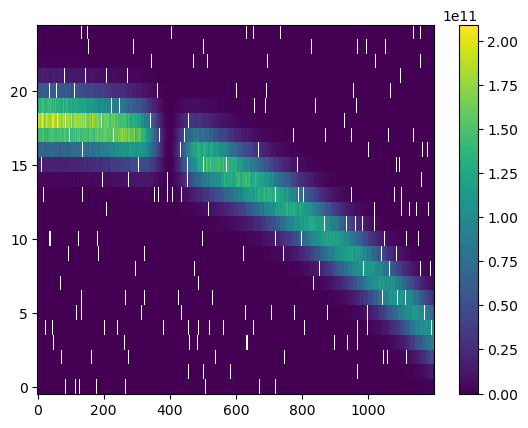

In [43]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v5(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)

    xlower = int(math.floor((x - xsi - 1/2)*oversampling - 1) + psf_x.shape[0]/2)
    xupper = int(math.ceil((x - xsi + 1/2)*oversampling + 2) + psf_x.shape[0]/2)
    xrng = xupper - xlower
    ylower = int(math.floor((y - ysi - 1/2)*oversampling - 1) + psf_x.shape[1]/2)
    yupper = int(math.ceil((y - ysi + 1/2)*oversampling + 2) + psf_x.shape[1]/2)
    yrng = yupper - ylower

    for iraw in range(xrng):
        for jraw in range(yrng):
            #i = xlower + iraw
            j = ylower + jraw
            i = xlower + (iraw + tidx) % xrng
            #j = ylower + (jraw + tidx) % yrng

            
            xpi = xo + psf_x[i, j]
            ypi = yo + psf_y[i, j]

            ox = pixel_slope * abs(xpi) + pixel_intercept
            oy = pixel_slope * abs(ypi) + pixel_intercept

            if ox <= 0 or oy <= 0:
                continue

            ox = max(float32(0), min(float32(1), ox))
            oy = max(float32(0), min(float32(1), oy))


            flux_contrib += ox*oy*fsi*psf_flux[i, j]
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(np.ascontiguousarray(psf_x, dtype=np.float32))
psf_yc = cuda.to_device(np.ascontiguousarray(psf_y, dtype=np.float32))
psf_flux = cuda.to_device(np.ascontiguousarray(psf_flux, dtype=np.float32))

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v5[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
#plt.imshow(outslitall.copy_to_host()[..., 0], aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v5[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 


    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

Or a float2-like approach

5.163167953491211 ms


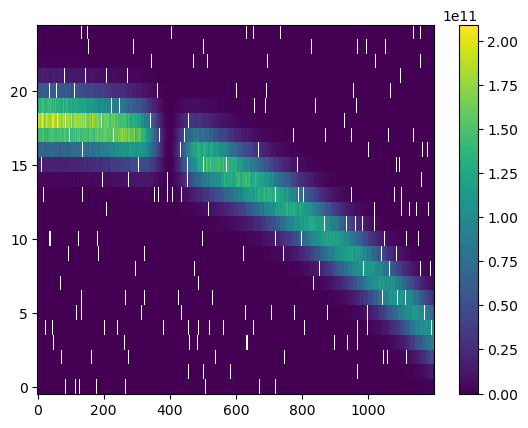

In [26]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v6(xspec, yspec, fluxspec,
                 psf, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)

    xlower = int(math.floor((x - xsi - 1/2)*oversampling - 1) + psf_x.shape[0]/2)
    xupper = int(math.ceil((x - xsi + 1/2)*oversampling + 2) + psf_x.shape[0]/2)
    xrng = xupper - xlower
    ylower = int(math.floor((y - ysi - 1/2)*oversampling - 1) + psf_x.shape[1]/2)
    yupper = int(math.ceil((y - ysi + 1/2)*oversampling + 2) + psf_x.shape[1]/2)
    yrng = yupper - ylower

    for iraw in range(xrng):
        for jraw in range(yrng):
            i = xlower + iraw
            #i = xlower + (iraw + tidx) % xrng
            j = ylower + jraw
            #j = ylower + (jraw + tidx) % yrng
            psfi = psf[i, j]
            xpi = xo + psfi.x
            ypi = yo + psfi.y

            ox = pixel_slope * abs(xpi) + pixel_intercept
            oy = pixel_slope * abs(ypi) + pixel_intercept

            if ox <= 0 or oy <= 0:
                continue

            ox = max(float32(0), min(float32(1), ox))
            oy = max(float32(0), min(float32(1), oy))


            flux_contrib += ox*oy*fsi*psfi.f
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

float3_dtype = np.dtype([('x', np.float32), ('y', np.float32), ('f', np.float32)])
host_psf_xyf = np.empty(psf_x.shape, dtype=float3_dtype)
host_psf_xyf['x'] = psf_x.astype(np.float32)
host_psf_xyf['y'] = psf_y.astype(np.float32)
host_psf_xyf['f'] = os_psf.astype(np.float32)
psfc = cuda.to_device(host_psf_xyf)

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v6[kernelspec](xspecc, yspecc, fluxpecc, 
                         psfc,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
#plt.imshow(outslitall.copy_to_host()[..., 0], aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v6[kernelspec](xspecc, yspecc, fluxpecc, 
                            psfc,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 


    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

OK thats no help... what if we try flattening and manual striding?

7.007999897003174 ms


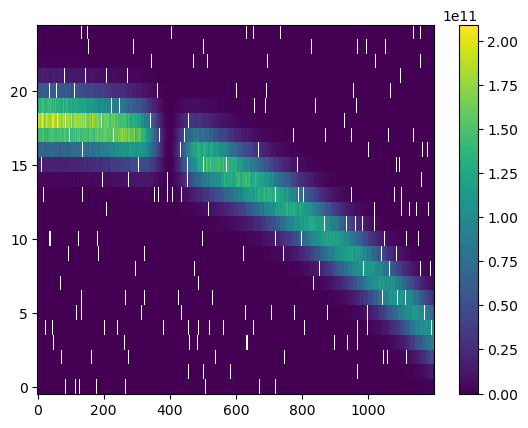

In [27]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

psf_block_size = int(200)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_v7(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outslitall):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if math.isnan(outslitall[y, x, tidx]):
        return

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]
    fsi = fluxspec[specidx]

    flux_contrib = float32(0)
    xo = float32(xsi) - float32(x)
    yo = float32(ysi) - float32(y)

    xlower = int(math.floor((x - xsi - 1/2)*oversampling - 1) + psf_block_size/2)
    xupper = int(math.ceil((x - xsi + 1/2)*oversampling + 2) + psf_block_size/2)
    xrng = xupper - xlower
    ylower = int(math.floor((y - ysi - 1/2)*oversampling - 1) + psf_block_size/2)
    yupper = int(math.ceil((y - ysi + 1/2)*oversampling + 2) + psf_block_size/2)
    yrng = yupper - ylower

    for iraw in range(xrng):
        for jraw in range(yrng):
            #i = xlower + iraw
            # j = ylower + jraw
            # i = xlower + (iraw + tidx) % xrng
            #j = ylower + (jraw + tidx) % yrng
            iarr = int(xlower + iraw) * psf_block_size + int(ylower + int(jraw + int(tidx)) % yrng)

            xpi = xo + psf_x[iarr]
            ypi = yo + psf_y[iarr]

            ox = pixel_slope * abs(xpi) + pixel_intercept
            oy = pixel_slope * abs(ypi) + pixel_intercept

            if ox <= 0 or oy <= 0:
                continue

            ox = max(float32(0), min(float32(1), ox))
            oy = max(float32(0), min(float32(1), oy))

            flux_contrib += ox*oy*fsi*psf_flux[iarr]
            
    outslitall[y, x, tidx] = flux_contrib

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.astype(np.float32).ravel())
psf_yc = cuda.to_device(psf_y.astype(np.float32).ravel())
psf_flux = cuda.to_device(os_psf.astype(np.float32).ravel())

slitarr = np.zeros_like(slit)
slitarr[np.isnan(slit)] = np.nan
outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))


scatter_flux_v7[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outslitall)


plt.imshow(np.sum(outslitall, axis=-1), aspect='auto', interpolation='nearest', origin='lower')
#plt.imshow(outslitall.copy_to_host()[..., 0], aspect='auto', interpolation='nearest', origin='lower')
plt.colorbar()


# we do it a second time for timing purposes since the first time may include some jitting
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    outslitall = cuda.to_device(np.repeat(np.expand_dims(slitarr, axis=-1), kernelspec[-1], axis=-1))

    start_evt.record() 
    scatter_flux_v7[kernelspec](xspecc, yspecc, fluxpecc, 
                            psf_xc, psf_yc, psf_flux,
                            startidxc, nspecc, 
                            outslitall)
    end_evt.record()  
    end_evt.synchronize() 


    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

Ok it makes no sense that that is *worse*??

This probably means the only real solution is to re-think so that the grid is aligned with the PSF?  But we're within range of a reasonable speed anyway so lets carry on for now.

For information's sake lets try recording the boundaries

In [78]:
pixel_slope = float32(-oversampling)
pixel_intercept = float32((1+oversampling)/2)

psf_block_size = int(200)

@cuda.jit(lineinfo=True)#(cache=True)
def scatter_flux_bounds(xspec, yspec, fluxspec,
                 psf_x, psf_y, psf_flux, 
                 startidx, nspec, 
                 outxylu):
    x = cuda.blockIdx.x
    y = cuda.blockIdx.y
    tidx = cuda.threadIdx.x

    if tidx >= nspec[y, x]:
        return
    
    specidx = tidx + startidx[y, x]
    
    xsi = xspec[specidx]
    ysi = yspec[specidx]

    xlower = int(math.floor((x - xsi - 1/2)*oversampling - 1) + psf_block_size/2)
    xupper = int(math.ceil((x - xsi + 1/2)*oversampling + 2) + psf_block_size/2)
    ylower = int(math.floor((y - ysi - 1/2)*oversampling - 1) + psf_block_size/2)
    yupper = int(math.ceil((y - ysi + 1/2)*oversampling + 2) + psf_block_size/2)

    outxylu[y, x, tidx, 0] = xlower
    outxylu[y, x, tidx, 1] = xupper
    outxylu[y, x, tidx, 2] = ylower
    outxylu[y, x, tidx, 3] = yupper

fluxpecc = cuda.to_device(spectrum_fnu.astype(np.float32))

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))

psf_xc = cuda.to_device(psf_x.astype(np.float32).ravel())
psf_yc = cuda.to_device(psf_y.astype(np.float32).ravel())
psf_flux = cuda.to_device(os_psf.astype(np.float32).ravel())

outxylu = cuda.to_device(-np.ones(list(slitarr.shape)+[kernelspec[-1], 4], dtype=int))


scatter_flux_bounds[kernelspec](xspecc, yspecc, fluxpecc, 
                         psf_xc, psf_yc, psf_flux,
                         startidxc, nspecc, 
                         outxylu)

xylu = outxylu.copy_to_host()

Text(0.5, 1.0, 'y upper')

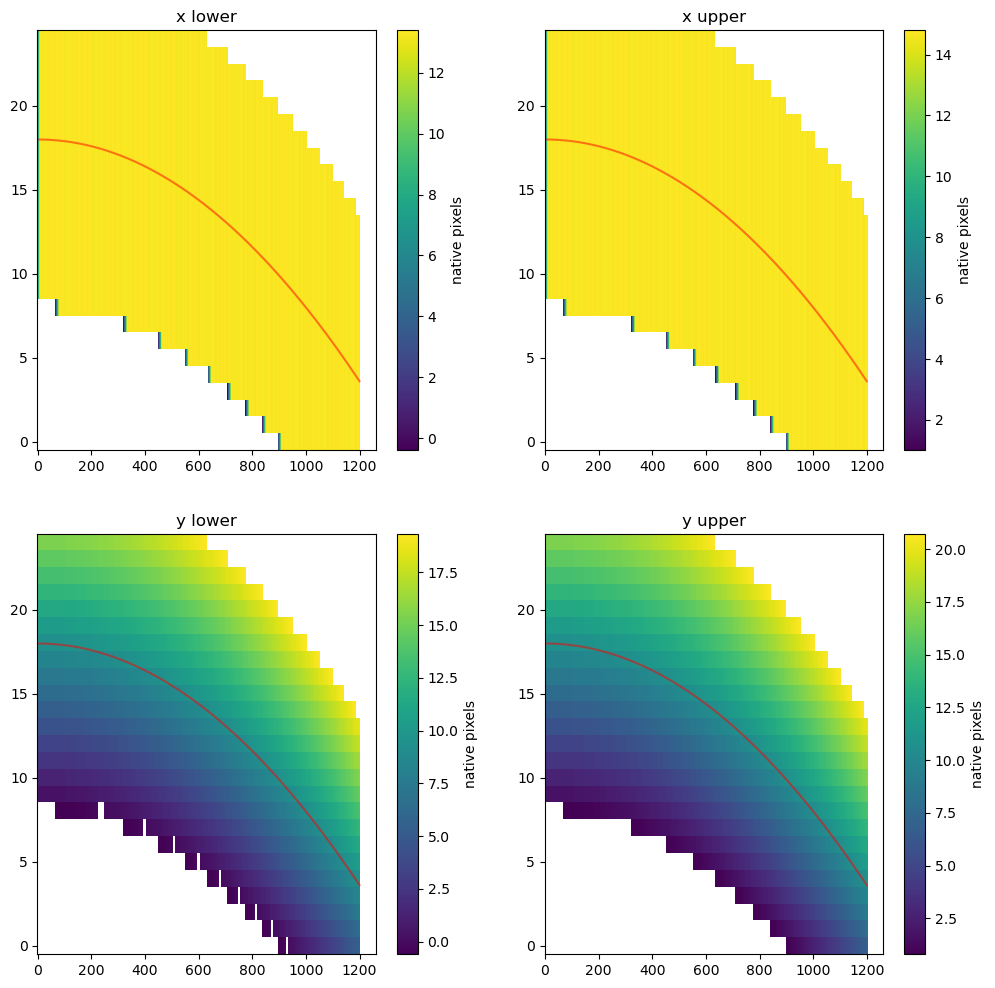

In [81]:
whichidx = 20

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

xyluf = xylu.astype(float)
xyluf[xylu==-1] = np.nan

for i, ax in enumerate(axs.ravel()):
    im = ax.imshow(xyluf[..., whichidx, i]/oversampling, aspect='auto', interpolation='nearest', origin='lower')
    plt.colorbar(im, ax=ax).set_label('native pixels')
    ax.plot(xspec, yspec, c='r', alpha=.5)

axs.ravel()[0].set_title('x lower')
axs.ravel()[1].set_title('x upper')
axs.ravel()[2].set_title('y lower')
axs.ravel()[3].set_title('y upper')

# Optimizing compute_influence

In [10]:
if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    
    xspecc = cuda.to_device(xspec)
    yspecc = cuda.to_device(yspec)
    startidxc = cuda.device_array(slit.shape, dtype=np.int32)
    nspecc = cuda.device_array(slit.shape, dtype=np.int32)

    start_evt.record() 
    # one thread per block is wasteful but this is just a test.
    compute_influence[slit.shape[::-1], 1](xspecc, yspecc, startidxc, nspecc)
    end_evt.record()  
    end_evt.synchronize() 

    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

23.904415130615234 ms


In [11]:
kernelspec_influence = (slit.shape[1], slit.shape[0])

maxpsf = max(np.max(psf_x), np.max(psf_y)).astype(np.float32).ravel()

@cuda.jit
def compute_influence_v2(xspec, yspec, startidx, nspec):
    x = cuda.blockIdx.x
    y = cuda.threadIdx.x

    startidxi = -1
    count = 0
    for i, (xs, ys) in enumerate(zip(xspec, yspec)):
        if abs(x - xs) <= maxpsf[0]:  #TODO: might need some buffer?
            if abs(y - ys) <= maxpsf[0]:
                count += 1
                if startidxi == -1:
                    startidxi = i
    
    startidx[y, x] = startidxi
    nspec[y, x] = count
                

xspecc = cuda.to_device(xspec)
yspecc = cuda.to_device(yspec)
startidxc = cuda.device_array(slit.shape, dtype=np.int32)
nspecc = cuda.device_array(slit.shape, dtype=np.int32)

compute_influence_v2[kernelspec_influence](xspecc, yspecc, startidxc, nspecc)

if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    

    start_evt.record() 
    # one thread per block is wasteful but this is just a test.
    compute_influence_v2[kernelspec_influence](xspecc, yspecc, startidxc, nspecc)
    end_evt.record()  
    end_evt.synchronize() 

    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

0.997376024723053 ms


In [ ]:
kernelspec_influence = (slit.shape[1], slit.shape[0])

maxpsf = max(np.max(psf_x), np.max(psf_y)).astype(np.float32).ravel()
maxpsfc = float32(maxpsf[0])

@cuda.jit
def compute_influence_v3(xspec, yspec, startidx, nspec):
    x = cuda.blockIdx.x
    y = cuda.threadIdx.x

    startidxi = -1
    count = 0
    for i, (xs, ys) in enumerate(zip(xspec, yspec)):
        if abs(float32(x) - xs) <= maxpsfc:
            if abs(float32(y) - ys) <= maxpsfc:
                count += 1
                if startidxi == -1:
                    startidxi = i
    
    startidx[y, x] = startidxi
    nspec[y, x] = count
                

xspecc = cuda.to_device(xspec.astype(np.float32))
yspecc = cuda.to_device(yspec.astype(np.float32))
startidxc = cuda.device_array(slit.shape, dtype=np.int32)
nspecc = cuda.device_array(slit.shape, dtype=np.int32)

compute_influence_v3[kernelspec_influence](xspecc, yspecc, startidxc, nspecc)

if do_timing_run:
    start_evt = cuda.event(timing=True)
    end_evt = cuda.event(timing=True)
    

    start_evt.record() 
    # one thread per block is wasteful but this is just a test.
    compute_influence_v3[kernelspec_influence](xspecc, yspecc, startidxc, nspecc)
    end_evt.record()  
    end_evt.synchronize() 

    print(cuda.event_elapsed_time(start_evt, end_evt), 'ms')

0.2979840040206909 ms
